 # — Import Libraries

In [1]:
# Block 1 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline
sns.set_style("whitegrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


# — Load & Inspect Data

In [5]:
# Block 2 — Load & Inspect Data
# Load dataset (update path if needed)
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Basic inspection
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())

Shape: (7043, 21)

Column Names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

First 5 rows:
    custome

# — Check & Clean Data

In [7]:
# Block 3 — Check & Clean Data
# Check missing values
print("Missing Values:\n", df.isnull().sum())

# TotalCharges has spaces - fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with null TotalCharges (only ~11 rows)
df.dropna(subset=['TotalCharges'], inplace=True)

# Convert Churn to numeric
df['ChurnNum'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

print("\nCleaned Shape:", df.shape)
print("Null values remaining:\n", df.isnull().sum())

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Cleaned Shape: (7032, 22)
Null values remaining:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn            

# — Churn Distribution Plot

C:\Users\HARSH JHA\AppData\Local\Temp\ipykernel_27780\2318870932.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette=['#2ecc71','#e74c3c'])


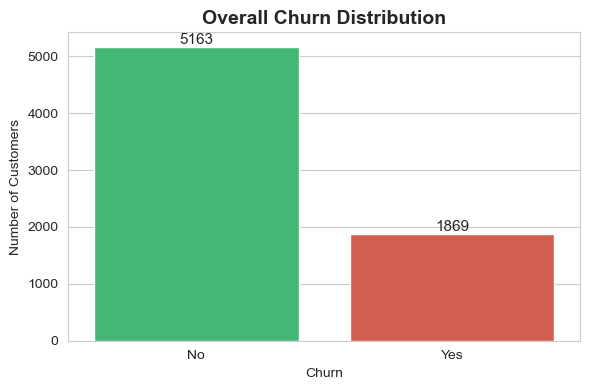

In [9]:
# Block 4 — Churn Distribution Plot
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Churn', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Overall Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

#  — Churn by Contract Type

C:\Users\HARSH JHA\AppData\Local\Temp\ipykernel_27780\2686692911.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Contract', y='ChurnRate', data=contract_churn, palette='Reds_d')


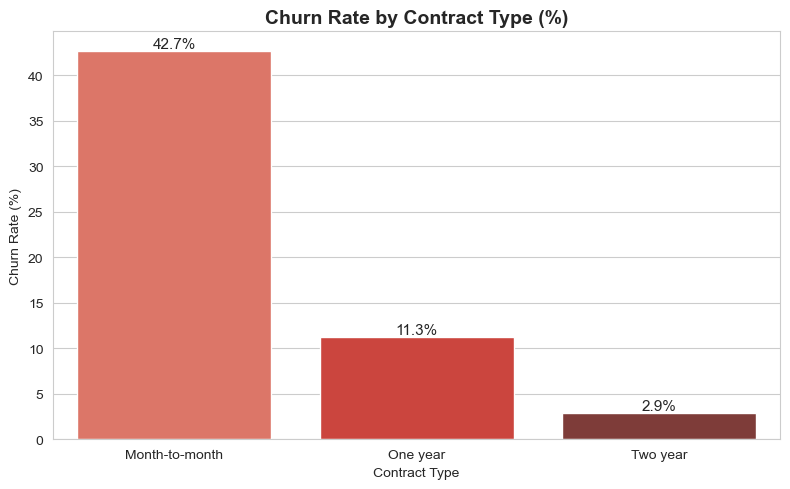

In [11]:
# Block 5 — Churn by Contract Type
plt.figure(figsize=(8,5))
contract_churn = df.groupby('Contract')['ChurnNum'].mean().reset_index()
contract_churn['ChurnRate'] = (contract_churn['ChurnNum'] * 100).round(2)

ax = sns.barplot(x='Contract', y='ChurnRate', data=contract_churn, palette='Reds_d')
plt.title('Churn Rate by Contract Type (%)', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150)
plt.show()

# Monthly Charges vs Churn

C:\Users\HARSH JHA\AppData\Local\Temp\ipykernel_27780\2920906908.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['#3498db','#e74c3c'])


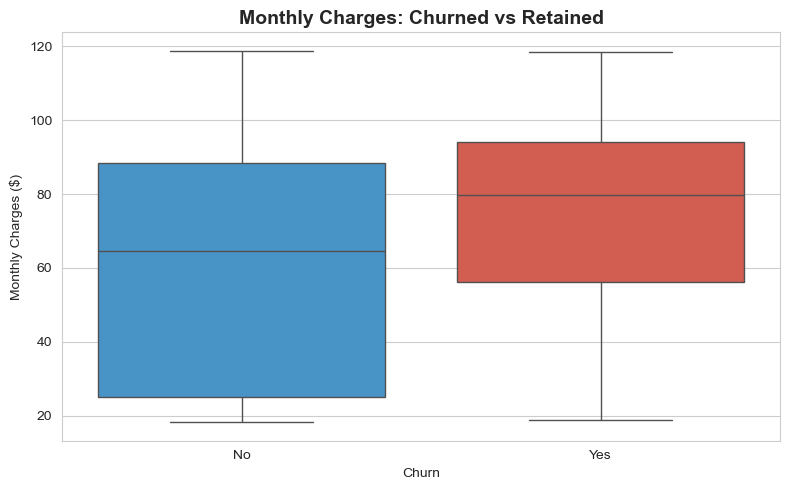

In [15]:
# Block 6 — Monthly Charges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['#3498db','#e74c3c'])
plt.title('Monthly Charges: Churned vs Retained', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('monthly_charges_churn.png', dpi=150)
plt.show()

# — Tenure vs Churn

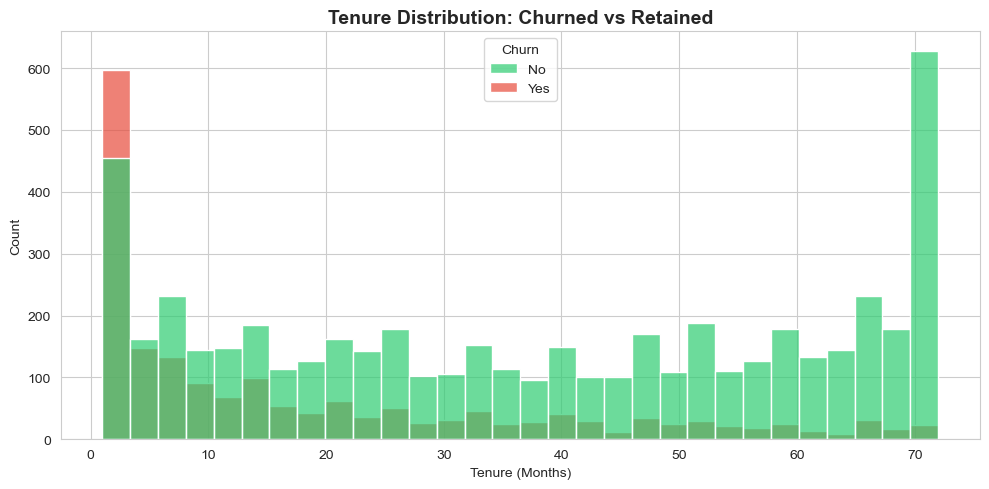

In [17]:
# Block 7 — Tenure vs Churn
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, 
             palette=['#2ecc71','#e74c3c'], alpha=0.7)
plt.title('Tenure Distribution: Churned vs Retained', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('tenure_churn.png', dpi=150)
plt.show()

# — Key Insights Summary

In [23]:
# Block 8 — Key Insights Summary
total = len(df)
churned = df['ChurnNum'].sum()
churn_rate = round(churned/total*100, 2)

print("=" * 40)
print("       KEY INSIGHTS SUMMARY")
print("=" * 40)
print(f"Total Customers     : {total}")
print(f"Churned Customers   : {churned}")
print(f"Overall Churn Rate  : {churn_rate}%")
print()

contract_rates = df.groupby('Contract')['ChurnNum'].mean()*100
print("Churn Rate by Contract:")
print(contract_rates.round(2))
print()

avg_charges = df.groupby('Churn')['MonthlyCharges'].mean()
print("Avg Monthly Charges:")
print(avg_charges.round(2))

       KEY INSIGHTS SUMMARY
Total Customers     : 7032
Churned Customers   : 1869
Overall Churn Rate  : 26.58%

Churn Rate by Contract:
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: ChurnNum, dtype: float64

Avg Monthly Charges:
Churn
No     61.31
Yes    74.44
Name: MonthlyCharges, dtype: float64
